In [1]:
import duckdb
from functions.evaluation import evaluate
from networks.oligoclonal_network import OligoclonalModel
from networks.oligoclonal_network import build_dataloader


con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT row_id, value, set, interpretation,label
                 FROM protein_data
                 WHERE value IS NOT NULL
                 AND observation_nr = 1
                 AND analysis IS NOT NULL
                 AND protein_value IS NOT NULL
                 """).df()
con.close()

correct_label = df['label'] == 6

valid_text = df['interpretation'].apply(lambda x: 1 if 'oligoklonal' in str(x).lower() else 0)
df['label'] = ((correct_label) | (valid_text)).astype(int)


train_rows = df[df['set'] == 'train']
val_rows   = df[df['set'] == 'val']
test_rows  = df[df['set'] == 'test']

drop_indices = train_rows[train_rows['label'] == 0].sample(frac=0.85).index

train_rows = train_rows.drop(drop_indices)
train_rows = train_rows[train_rows['label'].isin([0,1])]
val_rows = val_rows[val_rows['label'].isin([0,1])]

print(f"Antal utan oligoklonalt-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 0])}")
print(f"Antal med oligoklonalt i träningsdatan: {len(train_rows[train_rows['label'] == 1])}")

Oligoclonal = OligoclonalModel()
train_dl = build_dataloader(train_rows)
val_dl = build_dataloader(val_rows)
test_dl = build_dataloader(test_rows)
Oligoclonal.retrain(train_dl=train_dl,val_dl=val_dl,patience=50)

Antal utan oligoklonalt-komponent i träningsdatan: 10077
Antal med oligoklonalt i träningsdatan: 2290
Epoch   0 | train: 0.6074 | val: 0.6276 | acc: 71.55% | AUC: 0.729  | LR: 0.001
  -> ny bästa modell sparad till ../models/oligoclonal_model.pth
Epoch   1 | train: 0.5999 | val: 0.5894 | acc: 77.58% | AUC: 0.733  | LR: 0.001
  -> ny bästa modell sparad till ../models/oligoclonal_model.pth
Epoch   2 | train: 0.5858 | val: 0.6481 | acc: 69.96% | AUC: 0.739  | LR: 0.001
Epoch   3 | train: 0.5770 | val: 0.6010 | acc: 73.68% | AUC: 0.746  | LR: 0.001
Epoch   4 | train: 0.5805 | val: 0.7436 | acc: 55.30% | AUC: 0.740  | LR: 0.001
Epoch   5 | train: 0.5806 | val: 0.6896 | acc: 62.45% | AUC: 0.751  | LR: 0.001
Epoch   6 | train: 0.5776 | val: 0.7287 | acc: 52.87% | AUC: 0.757  | LR: 0.0005
Epoch   7 | train: 0.5619 | val: 0.5298 | acc: 79.79% | AUC: 0.770  | LR: 0.0005
  -> ny bästa modell sparad till ../models/oligoclonal_model.pth
Epoch   8 | train: 0.5496 | val: 0.5602 | acc: 75.70% | AUC: 

KeyboardInterrupt: 

Totala mängd datapunkter: 8141
              precision    recall  f1-score   support

     Negativ       0.99      0.89      0.94      7888
     Positiv       0.19      0.85      0.31       253

    accuracy                           0.89      8141
   macro avg       0.59      0.87      0.63      8141
weighted avg       0.97      0.89      0.92      8141

[[6990  898]
 [  38  215]]
AUC: 0.9440236432585847
Accuracy:  88.50%
FN-rate:   15.02%  (farliga missade fall)
FP-rate:   11.38%  (onödiga larm)
Sensitivitet:   84.98%  (Sannolikhet att upptäcka ett positivt fall)
Specificitet:   88.62%  (Sannolikhet att korrekt klassificera ett negativt fall negativt)
AUC: 0.9440


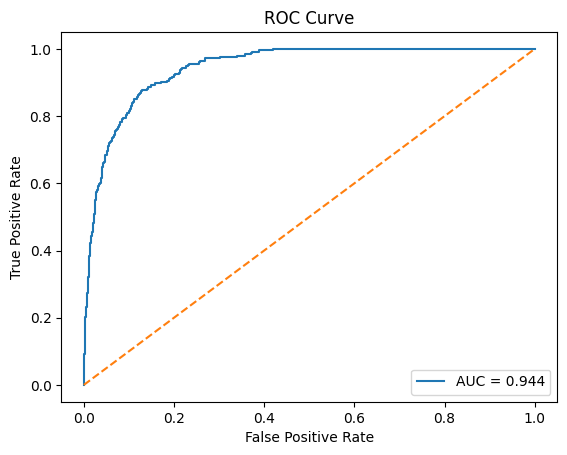

In [2]:
result = Oligoclonal.predict(test_rows)
df = Oligoclonal.evaluate(result,threshold=0.6)